In [1]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.api import qqplot
from linearmodels.panel import PanelOLS

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from tqdm.notebook import tqdm
from itables import init_notebook_mode
init_notebook_mode()

In [2]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet', columns=['idind', 'year', 'h7_2', 'h7_1', 'origsm', 'region', 'psu', 'status', 'age', 'educ', 'marst', 'h5', 'm20_7', 'j1', 'j60', 'j40', 'j363'])
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [3]:
panel = panel.with_columns(
    date = pl.concat_str([pl.col('year').cast(pl.Int32), pl.col('h7_2'), pl.col('h7_1').cast(pl.Int32)], separator=' ').str.strptime(pl.Date, format='%Y %B %d')
)
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [4]:
panel = panel.with_columns(
    is_employed = pl.when(pl.col('j1').is_in(['You are currently working', 'You are on paid leave: maternity leave or taking care of a child under 3 years o', 'You are on another kind of paid leave'])).then(1).otherwise(0)
)
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [5]:
panel['is_employed'].value_counts()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [6]:
panel = panel.with_columns(
    has_disablity = pl.when(pl.col('m20_7').is_in(['No', 'NO ANSWER'])).then(0).otherwise(1)
)
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [7]:
panel['has_disablity'].value_counts()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [8]:
panel = panel.with_columns(
    is_employed_has_disablity = pl.col('is_employed') * pl.col('has_disablity')
)
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [9]:
panel['is_employed_has_disablity'].value_counts()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [10]:
panel = panel.with_columns(
    is_employed_no_disablity = pl.col('is_employed') * pl.col('has_disablity').replace({0:1, 1:0})
)
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [11]:
panel['is_employed_no_disablity'].value_counts()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [12]:
panel = panel.with_columns(
    net_job = pl.col('j60').fill_null(0) - pl.col('j363').fill_null(0)
)
panel = panel.with_columns(
    pl.when(pl.col('net_job') < 0).then(0).otherwise('net_job').alias('net_job')
)
panel

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [13]:
net_job_income_compare = panel.filter(pl.col('net_job') < 1_000_000)
net_job_income_compare

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


<Axes: xlabel='has_disablity', ylabel='net_job'>

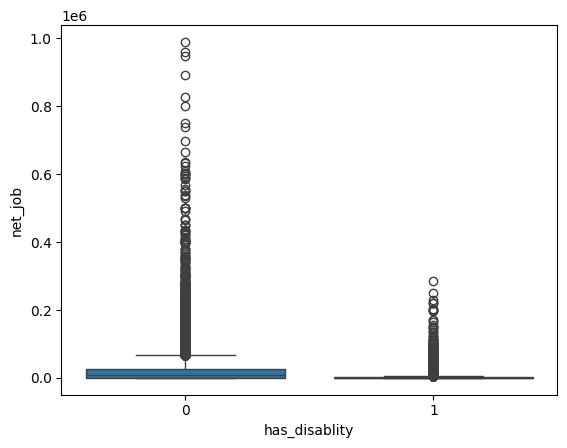

In [14]:
sns.boxplot(data=net_job_income_compare, y='net_job', x='has_disablity')

In [15]:
(
    net_job_income_compare
        .filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='has_disablity')

alt.Chart(...)

In [16]:
panel_working_pop = net_job_income_compare.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
panel_working_pop

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [17]:
(
    panel_working_pop
        .filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='has_disablity')

alt.Chart(...)

In [18]:
(
    panel_working_pop.filter(pl.col('is_employed_has_disablity') == 1)
    .group_by('year').len().sort('year')
).plot.line(x='year', y='len')

alt.Chart(...)

In [19]:
panel_working_pop_to_2020 = panel_working_pop.filter(
    pl.col('year').is_in([2019, 2020])
)
panel_working_pop_to_2020 = panel_working_pop_to_2020.with_columns(
    pl.when(pl.col('year') == 2020).then(1).otherwise(0).alias('covid_period')
).to_pandas().set_index(['idind', 'year'])
panel_working_pop_to_2020

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [20]:
agg_did_model = PanelOLS.from_formula('net_job ~ covid_period + EntityEffects + TimeEffects', panel_working_pop_to_2020, check_rank=False, drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
print(agg_did_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                     1.443e-14
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:               15358   R-squared (Within):               0.0000
Date:                Thu, Apr 09 2026   R-squared (Overall):              0.0000
Time:                        07:14:26   Log-likelihood                -1.633e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                          --
Entities:                        8982   P-value                               --
Avg Obs:                       1.7099   Distribution:                         --
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):                 --
                            

In [40]:
6.446e+04

64460.0

In [21]:
panel_working_pop_2019 = panel_working_pop.filter(
    pl.col('date').is_between(pl.date(2019, 1, 1), pl.date(2020, 1, 1))
)
panel_working_pop_2019

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [22]:
panel_working_pop_2020 = panel_working_pop.filter(
    pl.col('date').is_between(pl.date(2020, 1, 1), pl.date(2021, 1, 1))
)
panel_working_pop_2020

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [23]:
common_people = panel_working_pop_2019[['idind']].join(panel_working_pop_2020[['idind']], how='inner', on='idind')
common_people

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [24]:
panel_working_pop_common_2019_2020 = panel_working_pop.filter(
    pl.col('idind').is_in(common_people['idind'].implode())
)
panel_working_pop_common_2019_2020

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [25]:
panel_working_pop_common_2019_2020.filter(
    pl.col('is_employed_no_disablity') == 1
).group_by('year').len().plot.line(x='year', y='len')

alt.Chart(...)

In [26]:
panel_working_pop_common_2019_2020.filter(
    pl.col('is_employed_has_disablity') == 1
).group_by('year').len().plot.line(x='year', y='len')

alt.Chart(...)

In [27]:
(
    panel_working_pop_common_2019_2020
        .filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='has_disablity')

alt.Chart(...)

In [28]:
panel_working_pop_common_2019_2020.filter(
    pl.col('is_employed_has_disablity') == 1
).group_by('age').len()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


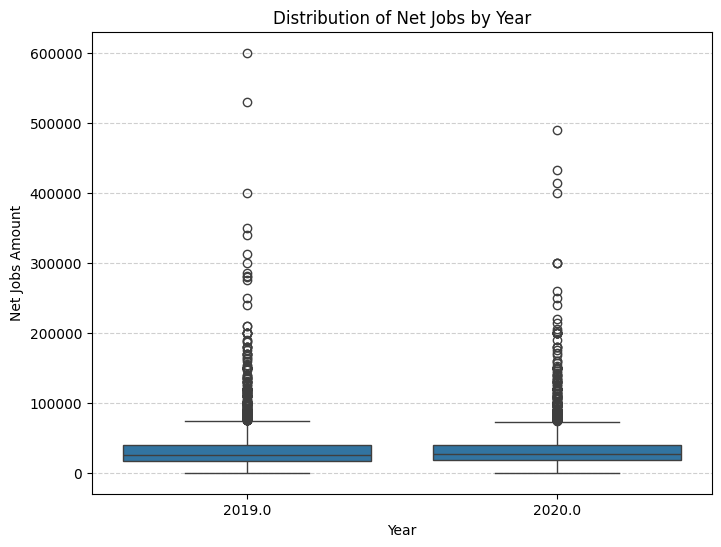

In [35]:
import matplotlib.pyplot as plt

tmp = panel_working_pop_common_2019_2020.filter(
    pl.col('year').is_in([2019, 2020])
)
df = pl.concat([
    tmp.filter(pl.col('year') == 2019)[['year', 'net_job']],
    tmp.filter(pl.col('year') == 2020)[['year', 'net_job']]
]).to_pandas()

# 2. (Optional but Highly Recommended) Convert 'year' to categorical/string
# This ensures seaborn treats the years as discrete categories, not a continuous number.
df['year'] = df['year'].astype(str)

# 3. Create the Boxplot
plt.figure(figsize=(8, 6)) # Set the size of the plot
sns.boxplot(x='year', y='net_job', data=df)

# 4. Add Titles and Labels for clarity
plt.title('Distribution of Net Jobs by Year')
plt.xlabel('Year')
plt.ylabel('Net Jobs Amount')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Optional: add horizontal grid lines
plt.show()

In [39]:
pl.concat([
    tmp.filter(pl.col('year') == 2019)[['year', 'net_job']],
    tmp.filter(pl.col('year') == 2020)[['year', 'net_job']]
]).group_by('year').mean()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


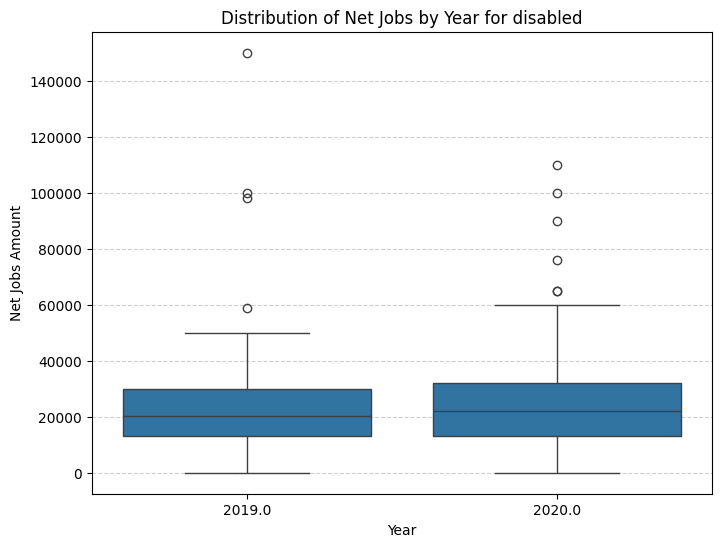

In [36]:
import matplotlib.pyplot as plt

tmp = panel_working_pop_common_2019_2020.filter(pl.col('is_employed_has_disablity') == 1).filter(
    pl.col('year').is_in([2019, 2020])
)
df = pl.concat([
    tmp.filter(pl.col('year') == 2019)[['year', 'net_job']],
    tmp.filter(pl.col('year') == 2020)[['year', 'net_job']]
]).to_pandas()

# 2. (Optional but Highly Recommended) Convert 'year' to categorical/string
# This ensures seaborn treats the years as discrete categories, not a continuous number.
df['year'] = df['year'].astype(str)

# 3. Create the Boxplot
plt.figure(figsize=(8, 6)) # Set the size of the plot
sns.boxplot(x='year', y='net_job', data=df)

# 4. Add Titles and Labels for clarity
plt.title('Distribution of Net Jobs by Year for disabled')
plt.xlabel('Year')
plt.ylabel('Net Jobs Amount')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Optional: add horizontal grid lines
plt.show()

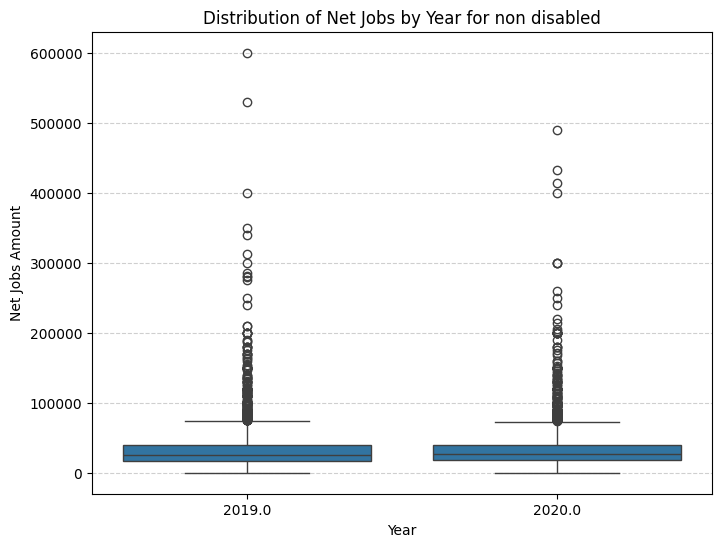

In [38]:
import matplotlib.pyplot as plt

tmp = panel_working_pop_common_2019_2020.filter(pl.col('is_employed_no_disablity') == 1).filter(
    pl.col('year').is_in([2019, 2020])
)
df = pl.concat([
    tmp.filter(pl.col('year') == 2019)[['year', 'net_job']],
    tmp.filter(pl.col('year') == 2020)[['year', 'net_job']]
]).to_pandas()

# 2. (Optional but Highly Recommended) Convert 'year' to categorical/string
# This ensures seaborn treats the years as discrete categories, not a continuous number.
df['year'] = df['year'].astype(str)

# 3. Create the Boxplot
plt.figure(figsize=(8, 6)) # Set the size of the plot
sns.boxplot(x='year', y='net_job', data=df)

# 4. Add Titles and Labels for clarity
plt.title('Distribution of Net Jobs by Year for non disabled')
plt.xlabel('Year')
plt.ylabel('Net Jobs Amount')
plt.grid(axis='y', linestyle='--', alpha=0.6) # Optional: add horizontal grid lines
plt.show()

In [31]:
# panel_working_pop_common_2019_2020.write_parquet('../data/panel_working_pop_common_2019_2020.parquet')

In [32]:
panel_working_pop_common_2019_2020_matched = pl.read_parquet('../data/panel_working_pop_common_2019_2020_matched.parquet')
panel_working_pop_common_2019_2020_matched

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [75]:
panel_working_pop_common_2019_2020_matched.filter(
    pl.col('is_employed_has_disablity') == 1
).group_by('year').len().plot.line(x='year', y='len')

alt.Chart(...)

In [76]:
panel_working_pop_common_2019_2020_matched.filter(
    pl.col('is_employed_no_disablity') == 1
).group_by('year').len().plot.line(x='year', y='len')

alt.Chart(...)

In [77]:
(
    panel_working_pop_common_2019_2020_matched
        .filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('net_job').mean())
).plot.line(x='year', y='net_job', color='has_disablity')

alt.Chart(...)

In [110]:
panel_working_pop_to_2020 = panel_working_pop_common_2019_2020_matched.filter(
    pl.col('idind').is_in(common_people['idind'].implode())
).filter(
    pl.col('year').is_in([2019, 2020])
)
panel_working_pop_to_2020 = panel_working_pop_to_2020.with_columns(
    pl.when(pl.col('year') == 2020).then(1).otherwise(0).alias('covid_period')
).to_pandas().set_index(['idind', 'year'])
panel_working_pop_to_2020

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [111]:
agg_did_model = PanelOLS.from_formula('net_job ~ covid_period + EntityEffects + TimeEffects', panel_working_pop_to_2020, check_rank=False, drop_absorbed=True).fit(cov_type='clustered', cluster_entity=True)
print(agg_did_model.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                net_job   R-squared:                     3.331e-16
Estimator:                   PanelOLS   R-squared (Between):              0.0000
No. Observations:                 472   R-squared (Within):               0.0000
Date:                Thu, Apr 09 2026   R-squared (Overall):              0.0000
Time:                        06:52:46   Log-likelihood                   -4838.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                          --
Entities:                         293   P-value                               --
Avg Obs:                       1.6109   Distribution:                         --
Min Obs:                       1.0000                                           
Max Obs:                       2.0000   F-statistic (robust):                 --
                            